In [2]:
# We'll plot sigma3 as a function of distance to filaments

import numpy as np
import matplotlib.pyplot as plt

from multidark_data_loader import *

_data = load_catalog()

data = select_sample(_data,-21.2)

print(data.keys())

Index(['x', 'y', 'z', 'vx', 'vy', 'vz', 'mag_abs_r', 'dist_fil'], dtype='str')


In [3]:
L = 1000.
coords = data[['x', 'y', 'z']].values
nn_dist = compute_knn_distance(coords, k=3, boxsize=L)
data['log_Sigma_3'] = np.log10( 3 / ((4 * np.pi * nn_dist**3) / 3)  )# density estimate

In [4]:
# Calculate the percentile that 0 falls under in the log_Sigma_3 distribution
percentile_0 = np.sum(data['log_Sigma_3'] < 0) / len(data) * 100
print(f"Percentile of log_Sigma_3 = 0: {percentile_0:.2f}%")

Percentile of log_Sigma_3 = 0: 97.29%


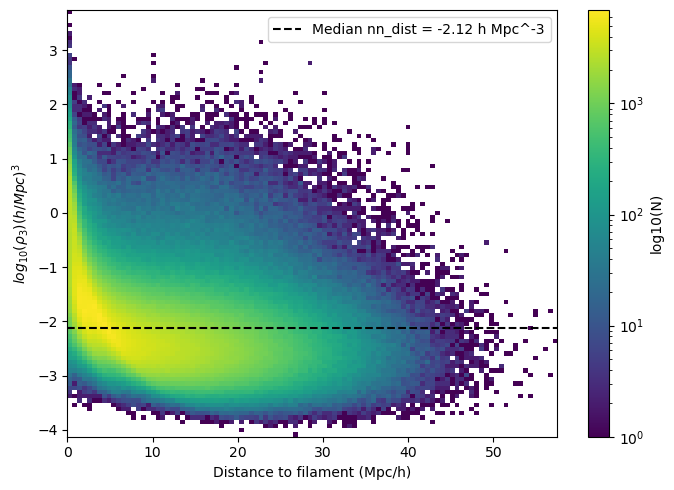

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
mask = data['dist_fil'] < 3.
plt.hist2d(data['dist_fil'], data['log_Sigma_3'], bins=100, norm='log', cmap='viridis')
#Plot horizontal line of median log_Sigma_3
median_log_Sigma_3 = np.median(data['log_Sigma_3'])
plt.axhline(median_log_Sigma_3, color='k', linestyle='--', label=f'Median nn_dist = {median_log_Sigma_3:.2f} h Mpc^-3')
#plt.axhline(-1.27, alpha=.5, color='k')
plt.colorbar(label='log10(N)')
plt.xlabel('Distance to filament (Mpc/h)')
plt.legend(loc='upper right')
plt.ylabel(r'$log_{10}(\rho_3) (h/Mpc)^{3}$')
plt.tight_layout()
#plt.savefig(f'../plots/dist_fil_vs_sigma{nearest_neighbor_n}.png', dpi=100)
plt.show()

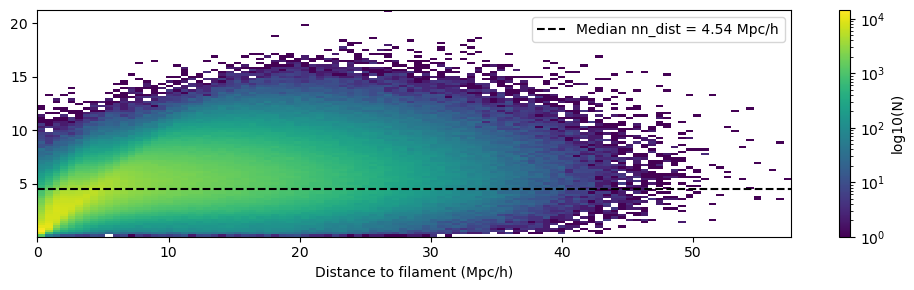

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.hist2d(data['dist_fil'], nn_dist, bins=100, norm='log', cmap='viridis')
# Plot a horizontal line at the median of nn_dist
plt.axhline(np.median(nn_dist), color='k', linestyle='--', label=f'Median nn_dist = {np.median(nn_dist):.2f} Mpc/h')
plt.colorbar(label='log10(N)')
plt.xlabel('Distance to filament (Mpc/h)')
plt.legend(loc='upper right')
#plt.ylabel(f'Sigma{nearest_neighbor_n} (Mpc/h)')
plt.tight_layout()
#plt.savefig(f'../plots/dist_fil_vs_sigma{nearest_neighbor_n}.png', dpi=100)
plt.show()

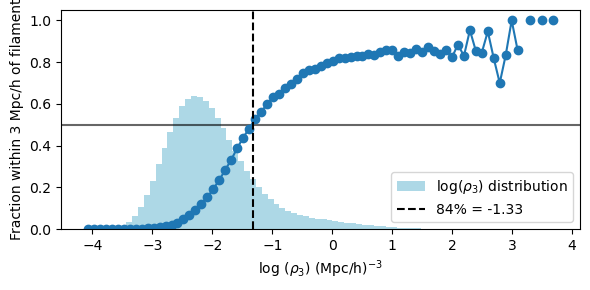

In [14]:
# How many galaxies are within 3 Mpc/h of a filament for a given sigma5?
# Let's fix sigma5 bins and calculate the fraction of galaxies within 3 Mpc/h of a filament in each bin
# Define bins and bin centers
sigma3_bins = np.linspace(data['log_Sigma_3'].min(), data['log_Sigma_3'].max(), 80)
bin_centers = (sigma3_bins[:-1] + sigma3_bins[1:]) / 2

# Assign bins (categorical), ensure all bins are kept in the groupby
data['log_Sigma3_bin'] = pd.cut(data['log_Sigma_3'], bins=sigma3_bins)

# Compute fraction per bin, including empty bins (observed=False)
bin_stats = data.groupby('log_Sigma3_bin', observed=False).apply(
    lambda df: np.mean(df['dist_fil'] < 3)
)

# Calculate percentiles for the fraction of galaxies within 3 Mpc/h of a filament
percentiles = np.percentile(data['log_Sigma_3'], [84])
styles = ['--']
labels = [84]  # for percentiles

# Plot with bin centers
plt.figure(figsize=(6, 3))
plt.hist(data['log_Sigma_3'], bins=80, alpha=1, \
         label=r'log($\rho_3$) distribution', density=True,\
            color='lightblue')
plt.axhline(.5, color='k', alpha=.6)
plt.plot(bin_centers, bin_stats, marker='o')
for i, ls in enumerate(styles):
    plt.axvline(percentiles[i], color='k', linestyle=ls,
                label=f'{labels[i]}% = {percentiles[i]:.2f}')
plt.legend(loc='lower right')
plt.xlabel(r'log ($\rho_3$) (Mpc/h)$^{-3}$')
plt.ylabel('Fraction within 3 Mpc/h of filament')
plt.tight_layout()
plt.show()

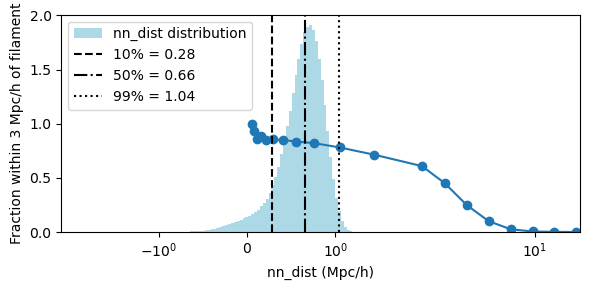

In [8]:
# Same for nndist
nn_dist_bins = np.geomspace(nn_dist.min(), nn_dist.max(), 20)
bin_centers = (nn_dist_bins[:-1] + nn_dist_bins[1:]) / 2

# Assign bins (categorical), ensure all bins are kept in the groupby
data['nn_dist_bin'] = pd.cut(nn_dist, bins=nn_dist_bins)

# Compute fraction per bin, including empty bins (observed=False)
bin_stats = data.groupby('nn_dist_bin', observed=False).apply(
    lambda df: np.mean(df['dist_fil'] < 3)
)

# Calculate percentiles for the fraction of galaxies within 3 Mpc/h of a filament
percentiles = np.percentile(np.log10(nn_dist), [10, 50, 99])
styles = ['--', '-.', ':']
labels = [10, 50, 99]  # for percentiles

# Plot with bin centers
plt.figure(figsize=(6, 3))
plt.hist(np.log10(nn_dist), bins=80, alpha=1, \
         label='nn_dist distribution', density=True,\
            color='lightblue')
plt.plot(bin_centers, bin_stats, marker='o')
for i, ls in enumerate(styles):
    plt.axvline(percentiles[i], color='k', linestyle=ls,
                label=f'{labels[i]}% = {percentiles[i]:.2f}')
plt.xscale('symlog')
plt.legend(loc='upper left')
plt.xlabel('nn_dist (Mpc/h)')
plt.ylabel('Fraction within 3 Mpc/h of filament')
plt.tight_layout()
plt.show()